In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


In [ ]:
adult = pd.read_csv('../data/adult.csv')
adult.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [3]:
X = adult.drop('income', axis=1)
y = adult['income'].map({'>50K': 1, '<=50K': 0})
X = pd.get_dummies(X, drop_first=True)
print('Features después de get_dummies:', X.shape)


Features después de get_dummies: (32561, 100)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
model = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


Accuracy: 0.8058143105742656


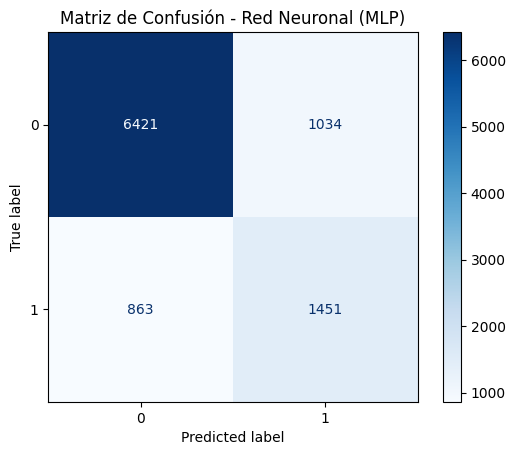

In [6]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Red Neuronal (MLP)')
plt.show()


In [7]:
sample = X_test.iloc[0:1]
sample_true = y_test.iloc[0]
sample_scaled = scaler.transform(sample)
sample_pred = model.predict(sample_scaled)[0]
sample_proba = model.predict_proba(sample_scaled)[0]
print('Predicción:', sample_pred, 'Etiqueta:', ('>50K' if sample_pred == 1 else '<=50K'))
print('Prob <=50K:', sample_proba[0])
print('Prob >50K:', sample_proba[1])
print('Valor real:', sample_true)


Predicción: 0 Etiqueta: <=50K
Prob <=50K: 0.9997998396186207
Prob >50K: 0.0002001603813793099
Valor real: 0
